100%|██████████| 12000/12000 [00:02<00:00, 5879.90it/s]


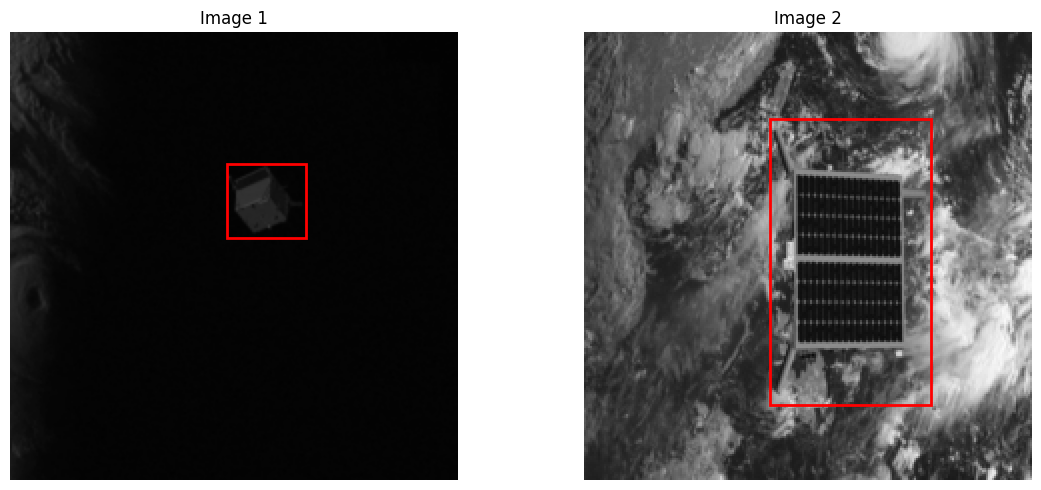

/tmp/ipykernel_19/496821741.py:595: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 225MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1 : Training loss: 0.629139                          
Epoch 2 : Training loss: 0.492134                          
Epoch 3 : Training loss: 0.454597                          
Epoch 4 : Training loss: 0.421323                          
Epoch 5 : Training loss: 0.393435 - Validation IoU: 0.525590 
Epoch 6 : Training loss: 0.376116                          
Epoch 7 : Training loss: 0.363173                          
Epoch 8 : Training loss: 0.353591                          
Epoch 9 : Training loss: 0.346392                          
Epoch 10 : Training loss: 0.338560 - Validation IoU: 0.633456 
Epoch 11 : Training loss: 0.331710                          
Epoch 12 : Training loss: 0.324412                          
Epoch 13 : Training loss: 0.319646                          
Epoch 14 : Training loss: 0.315909                          
Epoch 15 : Training loss: 0.312796 - Validation IoU: 0.722790 
Epoch 16 : Training loss: 0.310770                          
Epoch 17 : Training loss: 0

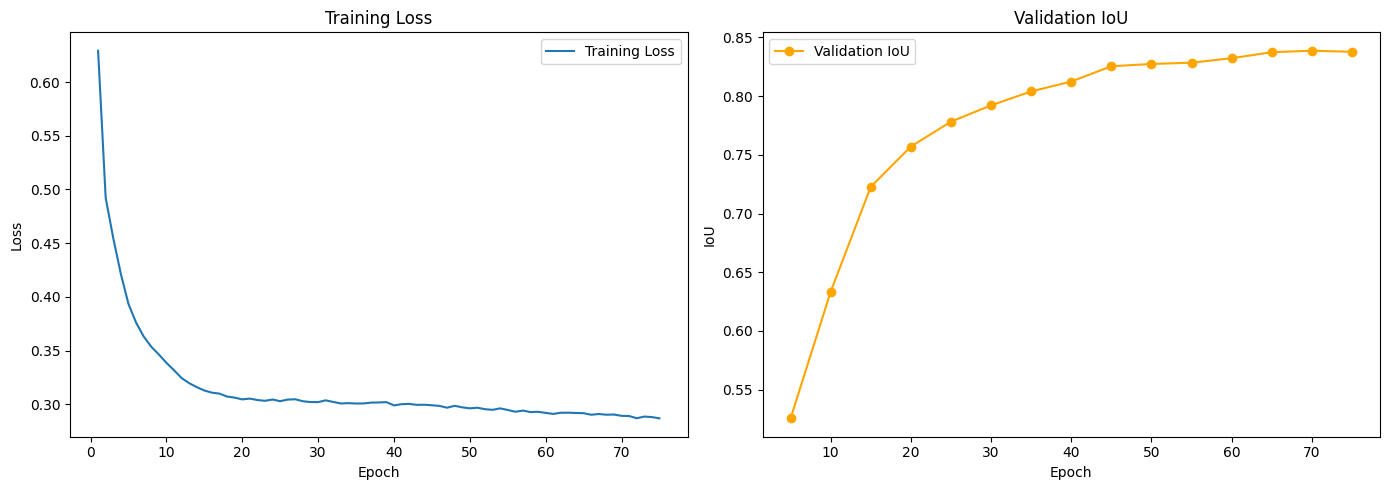

In [1]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn,optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models, ops
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.rpn import RegionProposalNetwork, RPNHead
from torchvision.models.detection.roi_heads import RoIHeads, fastrcnn_loss
from torchvision.models.detection.faster_rcnn import TwoMLPHead, FastRCNNPredictor
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchinfo import summary
from scipy.io import loadmat
from scipy.spatial.transform import Rotation as R
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import numpy as np
import tqdm
import math
from torch.jit.annotations import List, Dict

def load_tango_3d_keypoints(mat_dir):
    vertices  = loadmat(mat_dir)['tango3Dpoints'] # [3 x 11]
    corners3D = np.transpose(np.array(vertices, dtype=np.float32)) # [11 x 3]

    return corners3D

def load_camera_intrinsics(camera_json):
    with open(camera_json) as f:
        cam = json.load(f)
    cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
    distCoeffs   = np.array(cam['distCoeffs'],   dtype=np.float32)

    return cameraMatrix, distCoeffs

def quat2dcm(q):
    """ Computing direction cosine matrix from quaternion, adapted from PyNav.
    Arguments:
        q: (4,) numpy.ndarray - unit quaternion (scalar-first)
    Returns:
        dcm: (3,3) numpy.ndarray - corresponding DCM
    """

    # normalizing quaternion
    q = q/np.linalg.norm(q)

    q0 = q[0]
    q1 = q[1]
    q2 = q[2]
    q3 = q[3]

    dcm = np.zeros((3, 3))

    dcm[0, 0] = 2 * q0 ** 2 - 1 + 2 * q1 ** 2
    dcm[1, 1] = 2 * q0 ** 2 - 1 + 2 * q2 ** 2
    dcm[2, 2] = 2 * q0 ** 2 - 1 + 2 * q3 ** 2

    dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
    dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2

    dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
    dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1

    dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
    dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1

    return dcm

def project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
    ''' Project keypoints.
    Arguments:
        q_vbs2tango:  (4,) numpy.ndarray - unit quaternion from VBS to Tango frame
        r_Vo2To_vbs:  (3,) numpy.ndarray - position vector from VBS to Tango in VBS frame (m)
        cameraMatrix: (3,3) numpy.ndarray - camera intrinsics matrix
        distCoeffs:   (5,) numpy.ndarray - camera distortion coefficients in OpenCV convention
        keypoints:    (3,N) or (N,3) numpy.ndarray - 3D keypoint locations (m)
    Returns:
        points2D: (2,N) numpy.ndarray - projected points (pix)
    '''
    # Size check (3,N)
    if keypoints.shape[0] != 3:
        keypoints = np.transpose(keypoints)

    # Keypoints into 4 x N homogenous coordinates
    keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))

    # transformation to image frame
    pose_mat = np.hstack((np.transpose(quat2dcm(q_vbs2tango)),
                          np.expand_dims(r_Vo2To_vbs, 1)))
    xyz      = np.dot(pose_mat, keypoints) # [3 x N]
    x0, y0   = xyz[0,:] / xyz[2,:], xyz[1,:] / xyz[2,:] # [1 x N] each

    # apply distortion
    r2 = x0*x0 + y0*y0
    cdist = 1 + distCoeffs[0]*r2 + distCoeffs[1]*r2*r2 + distCoeffs[4]*r2*r2*r2
    x  = x0*cdist + distCoeffs[2]*2*x0*y0 + distCoeffs[3]*(r2 + 2*x0*x0)
    y  = y0*cdist + distCoeffs[2]*(r2 + 2*y0*y0) + distCoeffs[3]*2*x0*y0

    # apply camera matrix
    points2D = np.vstack((cameraMatrix[0,0]*x + cameraMatrix[0,2],
                          cameraMatrix[1,1]*y + cameraMatrix[1,2]))

    return points2D

class Speed(Dataset):
    def __init__(self, images_dir, json_dir, transform=None):
        self.images_dir = images_dir
        self.json_dir = json_dir
        self.transform = transform

        self.num_classes = 1000
        self.num_neighbors = 5

        self.imagesList = []
        self.BBoxList = []
        self.keypointsList = []  #

        cnt=0

        keypts3d = load_tango_3d_keypoints('/kaggle/input/mat-file/tangoPoints.mat') # https://www.desmos.com/3d/jud6lng9gn
        cameraMatrix, distCoeffs = load_camera_intrinsics('/kaggle/input/mat-file/camera.json')

        with open(self.json_dir, 'r') as f:
            annotations = json.load(f)
            lookup = { item['filename']: item for item in annotations }


            for filename in tqdm.tqdm(os.listdir(self.images_dir)):
                if filename not in lookup:
                    continue
                self.imagesList.append(os.path.join(self.images_dir, filename))

                q_vbs2tango = np.array(lookup[filename]["q_vbs2tango"], dtype=np.float32)
                r_Vo2To_vbs = np.array(lookup[filename]['r_Vo2To_vbs_true'], dtype=np.float32)

                keypts2d = project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypts3d) # (2, 11)
                
                # Store the 2D keypoints for this image
                self.keypointsList.append(torch.tensor(keypts2d, dtype=torch.float32))
                
                xmin = np.min(keypts2d[0])
                xmax = np.max(keypts2d[0])
                ymin = np.min(keypts2d[1])
                ymax = np.max(keypts2d[1])


                width = xmax - xmin
                height = ymax - ymin
                margin_x = width * 0.05
                margin_y = height * 0.05

                xmin = max(0, xmin - margin_x)
                xmax = xmax + margin_x
                ymin = max(0, ymin - margin_y)
                ymax = ymax + margin_y

                BBox = [xmin, xmax, ymin, ymax]

                self.BBoxList.append(torch.tensor(BBox, dtype=torch.float32))

                cnt=cnt+1
                # if cnt>50:
                #     break

    def __len__(self):
        return len(self.imagesList)

    def __getitem__(self, idx):
        image_path = self.imagesList[idx]
        image = Image.open(image_path).convert('RGB')
        orig_w, orig_h = image.size
        BBox = self.BBoxList[idx]
        keypoints = self.keypointsList[idx].clone()  

        new_w, new_h = orig_w, orig_h

        if self.transform:
            resize_transform = transforms.Resize((224, 224))
            image = resize_transform(image)
            new_w, new_h = 224, 224
            
            scale_x = new_w / orig_w
            scale_y = new_h / orig_h
            
            keypoints[0, :] *= scale_x 
            keypoints[1, :] *= scale_y  
            
            xmin, xmax, ymin, ymax = BBox.tolist()
            xmin *= scale_x
            xmax *= scale_x
            ymin *= scale_y
            ymax *= scale_y
            BBox = torch.tensor([xmin, xmax, ymin, ymax], dtype=BBox.dtype, device=BBox.device)
        
        if torch.rand(1) > 0.4:
            image = transforms.functional.hflip(image)
            keypoints[0, :] = new_w - keypoints[0, :]
            xmin, xmax, ymin, ymax = BBox.tolist()
            new_xmin = new_w - xmax
            new_xmax = new_w - xmin
            BBox = torch.tensor([new_xmin, new_xmax, ymin, ymax], dtype=BBox.dtype, device=BBox.device)

        
        if torch.rand(1) > 0.4:
            angles = [0, 90, 180, 270]
            angle = angles[torch.randint(0, len(angles), (1,)).item()]
            
            if angle != 0:  
                image = transforms.functional.rotate(image, -angle)  
                keypoints_rotated = torch.zeros_like(keypoints)
                
                if angle == 90:
                    keypoints_rotated[0, :] = new_h - keypoints[1, :]
                    keypoints_rotated[1, :] = keypoints[0, :]
                elif angle == 180:
                    keypoints_rotated[0, :] = new_w - keypoints[0, :]
                    keypoints_rotated[1, :] = new_h - keypoints[1, :]
                elif angle == 270:
                    keypoints_rotated[0, :] = keypoints[1, :]
                    keypoints_rotated[1, :] = new_w - keypoints[0, :]
                
                keypoints = keypoints_rotated
                
                margin = 0.05
                xmin = keypoints[0, :].min()
                xmax = keypoints[0, :].max()
                ymin = keypoints[1, :].min()
                ymax = keypoints[1, :].max()
                
                width = xmax - xmin
                height = ymax - ymin
                xmin = max(0, xmin - margin * width)
                xmax = xmax + margin * width
                ymin = max(0, ymin - margin * height)
                ymax = ymax + margin * height
                
                BBox = torch.tensor([xmin, xmax, ymin, ymax], 
                                   dtype=BBox.dtype, device=BBox.device)

        if self.transform:
            color_jitter = transforms.RandomApply([
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
            ], p=0.5)
            to_tensor = transforms.ToTensor()
            
            image = to_tensor(color_jitter(image))

        return image, BBox

transform = transforms.Compose([
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
    ], p=0.5),
    transforms.ToTensor(),
])
    

dataset = Speed(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', transform=transform)

train_size= int(0.8* len(dataset))
train_data, val_data = random_split(dataset, [train_size, len(dataset) - train_size])



num_images = min(2, len(dataset))
per_row = 2
rows = (num_images + per_row - 1) // per_row

plt.figure(figsize=(12, rows * 5))
for i in range(num_images):
    plt.subplot(rows, per_row, i + 1)
    image, BBox = dataset[i]
    xmin, xmax, ymin, ymax = BBox

    plt.imshow(image.permute(1, 2, 0))
    plt.gca().add_patch(
        plt.Rectangle((xmin, ymin),
                      xmax - xmin,
                      ymax - ymin,
                      fill=False,
                      edgecolor='red',
                      linewidth=2)
    )
    plt.title(f"Image {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

class SPN(nn.Module):
    def __init__(self, num_classes=1000, keep_prob=0.5, pretrain=True):
        super().__init__()

        self.num_classes = num_classes
        self.regress_size = self.num_classes
        self.keep_prob = keep_prob

        # RPN parameters with improved defaults
        self.rpn_pre_nms_top_n_train = 2000  # Increased from 500
        self.rpn_pre_nms_top_n_test = 1000   # Increased from 250
        self.rpn_post_nms_top_n_train = 2000 # Increased from 100
        self.rpn_post_nms_top_n_test = 1000  # Increased from 50
        
        # Better anchor configuration for multi-feature map FPN
        # Each tuple in the main tuple corresponds to one feature map
        self.anchor_sizes = ((32,), (64,), (128,), (256,), (256,))  # 5 feature maps (p2, p3, p4, p5, p6)
        self.aspect_ratios = ((0.5, 1.0, 2.0),) * 5  # Same aspect ratios for all feature maps
        self.num_anchors = len(self.aspect_ratios[0])

        # Image transform parameters - adjusted for 224x224 input
        self.min_size = 224
        self.max_size = 224
        self.image_mean = [0.485, 0.456, 0.406]
        self.image_std = [0.229, 0.224, 0.225]

        # Image transform adjusted for 224x224 input size
        self.transform = GeneralizedRCNNTransform(
            min_size=self.min_size,
            max_size=self.max_size,
            image_mean=self.image_mean,
            image_std=self.image_std
        )
        
        # Use ResNet-50 as the backbone with pretrained weights
        backbone = models.resnet50(weights="IMAGENET1K_V1" if pretrain else None)
        
        # Use only the features from the backbone (remove classification head)
        self.backbone_layers = nn.ModuleList([
            nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool),
            backbone.layer1,
            backbone.layer2,
            backbone.layer3,
            backbone.layer4
        ])
        
        # FPN with lateral connections for multi-scale feature fusion
        self.fpn_channels = 256
        
        # Lateral connections
        self.lateral_c2 = nn.Conv2d(256, self.fpn_channels, kernel_size=1)
        self.lateral_c3 = nn.Conv2d(512, self.fpn_channels, kernel_size=1)
        self.lateral_c4 = nn.Conv2d(1024, self.fpn_channels, kernel_size=1)
        self.lateral_c5 = nn.Conv2d(2048, self.fpn_channels, kernel_size=1)
        
        # Top-down layers
        self.fpn_p5 = nn.Conv2d(self.fpn_channels, self.fpn_channels, kernel_size=3, padding=1)
        self.fpn_p4 = nn.Conv2d(self.fpn_channels, self.fpn_channels, kernel_size=3, padding=1)
        self.fpn_p3 = nn.Conv2d(self.fpn_channels, self.fpn_channels, kernel_size=3, padding=1)
        self.fpn_p2 = nn.Conv2d(self.fpn_channels, self.fpn_channels, kernel_size=3, padding=1)
        
        # Extra P6 layer for larger feature map (for RPN)
        self.fpn_p6 = nn.Conv2d(self.fpn_channels, self.fpn_channels, kernel_size=3, stride=2, padding=1)
        
        # Attention module for feature refinement
        self.attention_module = nn.Sequential(
            nn.Conv2d(self.fpn_channels, self.fpn_channels // 16, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(self.fpn_channels // 16, self.fpn_channels, kernel_size=1),
            nn.Sigmoid()
        )
        
        # RPN on top of FPN (with shared weights across all levels)
        self.rpn = RegionProposalNetwork(
            anchor_generator=AnchorGenerator(sizes=self.anchor_sizes, aspect_ratios=self.aspect_ratios),
            head=RPNHead(in_channels=self.fpn_channels, num_anchors=self.num_anchors),
            fg_iou_thresh=0.7,
            bg_iou_thresh=0.3,
            batch_size_per_image=256,  # Increased from 128
            positive_fraction=0.5,
            pre_nms_top_n=dict(training=self.rpn_pre_nms_top_n_train, testing=self.rpn_pre_nms_top_n_test),
            post_nms_top_n=dict(training=self.rpn_post_nms_top_n_train, testing=self.rpn_post_nms_top_n_test),
            nms_thresh=0.7,
            score_thresh=0.0,
        )
        
        # Use default RoIHeads instead of CustomRoIHeads
        self.roi_heads = RoIHeads(
            box_roi_pool=ops.MultiScaleRoIAlign(
                featmap_names=['p2', 'p3', 'p4', 'p5'],  # Use features from all FPN levels
                output_size=7,
                sampling_ratio=2
            ),
            box_head=nn.Sequential(
                # Add a flattening operation as the first layer
                nn.Flatten(start_dim=1),
                nn.Linear(self.fpn_channels * 7 * 7, 1024),
                nn.ReLU(inplace=True),
                nn.Dropout(p=1-self.keep_prob),
                nn.Linear(1024, 1024),
                nn.ReLU(inplace=True),
                nn.Dropout(p=1-self.keep_prob)
            ),
            box_predictor=FastRCNNPredictor(1024, 2),  # Background + 1 foreground class
            fg_iou_thresh=0.5,
            bg_iou_thresh=0.5,
            batch_size_per_image=128,  # Increased from 64
            positive_fraction=0.25,
            bbox_reg_weights=None,
            score_thresh=0.05,
            nms_thresh=0.5,
            detections_per_img=1,
        )
        
        # Initialize weights for new layers
        for m in [self.lateral_c2, self.lateral_c3, self.lateral_c4, self.lateral_c5,
                 self.fpn_p2, self.fpn_p3, self.fpn_p4, self.fpn_p5, self.fpn_p6]:
            nn.init.kaiming_normal_(m.weight, mode='fan_out')
            nn.init.zeros_(m.bias)
            
        # If we have a pretrained model, load it
        if pretrain and os.path.exists("/kaggle/input/spnrpn/epoch_30_model_weights.pth"):
            try:
                state_dict = torch.load("/kaggle/input/spnrpn/epoch_30_model_weights.pth", map_location=torch.device('cpu'))
                # Only load backbone weights that match
                model_dict = self.state_dict()
                pretrained_dict = {k: v for k, v in state_dict.items() 
                                  if k in model_dict and v.shape == model_dict[k].shape}
                model_dict.update(pretrained_dict)
                self.load_state_dict(model_dict, strict=False)
                print(f"Loaded {len(pretrained_dict)}/{len(state_dict)} pretrained parameters")
            except Exception as e:
                print(f"Failed to load pretrained weights: {e}")
    
    def _apply_attention(self, x):
        """Apply channel-wise attention mechanism"""
        attention_weights = self.attention_module(x)
        return x * attention_weights
    
    def _upsample_add(self, x, y):
        """Upsample x and add to y"""
        _, _, H, W = y.shape
        return F.interpolate(x, size=(H, W), mode='nearest') + y
    
    def extract_features(self, x):
        """Extract features from backbone and build FPN"""
        # Bottom-up pathway
        c1 = self.backbone_layers[0](x)
        c2 = self.backbone_layers[1](c1)
        c3 = self.backbone_layers[2](c2)
        c4 = self.backbone_layers[3](c3)
        c5 = self.backbone_layers[4](c4)
        
        # Top-down pathway with lateral connections
        p5 = self.lateral_c5(c5)
        p4 = self._upsample_add(p5, self.lateral_c4(c4))
        p3 = self._upsample_add(p4, self.lateral_c3(c3))
        p2 = self._upsample_add(p3, self.lateral_c2(c2))
        
        # Apply convolutional layers on each level
        p2 = self.fpn_p2(p2)
        p3 = self.fpn_p3(p3)
        p4 = self.fpn_p4(p4)
        p5 = self.fpn_p5(p5)
        
        # Add attention mechanism
        p2 = self._apply_attention(p2)
        p3 = self._apply_attention(p3)
        p4 = self._apply_attention(p4)
        p5 = self._apply_attention(p5)
        
        # Extra level for larger feature map (used in RPN)
        p6 = self.fpn_p6(p5)
        
        return {'p2': p2, 'p3': p3, 'p4': p4, 'p5': p5, 'p6': p6}

    def forward(self, X, targets=None):
        images, targets = self.transform(X, targets)
        
        # Extract features through backbone + FPN
        features = self.extract_features(images.tensors)
        
        # RPN forward pass
        proposals, proposal_losses = self.rpn(images, features, targets=targets)
        
        # RoI heads forward pass
        detections, detector_losses = self.roi_heads(features, proposals, images.image_sizes, targets=targets)

        # Return losses during training and detections during inference
        if self.training:
            return proposal_losses, detector_losses
        else:
            return detections

def calculate_iou(box1, box2):
    """Calculate IoU between two boxes [x1, y1, x2, y2] format"""
    # Find the coordinates of the intersection
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    # Check if the boxes intersect
    if x2 < x1 or y2 < y1:
        return 0.0
    
    # Calculate area of intersection
    intersection = (x2 - x1) * (y2 - y1)
    
    # Calculate area of both boxes
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    # Calculate IoU
    iou = intersection / (box1_area + box2_area - intersection)
    
    return iou

def train_loop(train_dataloader, val_dataloader, model, optimizer, scheduler, scaler, batch_size, epoch):
     train_size = len(train_dataloader.dataset)
     num_batches = len(train_dataloader)
     loss_tot = 0
     for batch,(X, yBBox) in enumerate(train_dataloader):
        X, yBBox = X.to(device), yBBox.to(device)
        model.train()
        targets = []
        for i in range(len(X)):
            box = torch.tensor([yBBox[i][0], yBBox[i][2], yBBox[i][1], yBBox[i][3]], device=device).view(1, 4)
            target = {'boxes': box, 'labels': torch.ones(1, dtype=torch.int64, device=device)}
            targets.append(target)

        optimizer.zero_grad()

        with autocast(device_type='cuda'):
            proposal_losses, detector_losses = model(X, targets)
            loss = sum(proposal_losses.values()) + sum(detector_losses.values())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        loss_tot += loss.item()

        current = batch * batch_size + len(X)
        print(f"\rEpoch {epoch+1} : Training loss: {loss:>7f}  [{current:>5d}/{train_size:>5d}]", end="")


     loss_avg = loss_tot / num_batches

     print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f}                          ", end="")
     val_iou = 0
     val_size = len(val_dataloader.dataset)
     if (epoch+1) % 5 == 0:
         model.eval()
         total_iou = 0
         total_examples = 0
         
         with torch.no_grad():
            for batch, (X, yBBox) in enumerate(val_dataloader):
                X, yBBox = X.to(device), yBBox.to(device)
                
                with autocast(device_type='cuda'):
                    # Use the proper API for inference - just call the model directly
                    detections = model(X)
                
                batch_iou = 0
                for i in range(len(X)):
                    if len(detections[i]['boxes']) == 0:
                        continue
                    
                    scores = detections[i]['scores']
                    boxes = detections[i]['boxes']
                    if len(scores) > 0:
                        best_idx = torch.argmax(scores)
                        pred_box = boxes[best_idx].cpu()
                        
                        gt_box = torch.tensor([
                            yBBox[i][0], yBBox[i][2], 
                            yBBox[i][1], yBBox[i][3]
                        ]).cpu()
                        
                        iou = calculate_iou(pred_box, gt_box)
                        batch_iou += iou
                        total_iou += iou
                        total_examples += 1
                
                if len(X) > 0:
                    batch_iou /= len(X)
                
                current = batch * batch_size + len(X)
                print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Validation IoU: {batch_iou:>7f}  [{current:>5d}/{val_size:>5d}]", end="")

            avg_iou = total_iou / max(1, total_examples)  
            print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Validation IoU: {avg_iou:>7f} ")
            val_iou = avg_iou
     else:
         print("")

     return loss_avg, val_iou

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()
model=SPN().to(device)

learning_rate = 1e-3
batch_size = 16
epochs = 75
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.95)

train_dataloader = DataLoader(train_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_dataloader = DataLoader(val_data, batch_size, shuffle=False, num_workers=4, pin_memory=True)


loss_history = {'train': [], 'val_iou': []}  

best_train_loss = float('inf')
patience = 30  # How many epochs to wait after last improvement
patience_counter = 0
min_delta=0.001

# print(summary(model, (1,3,224,224)))

for t in range(epochs):
    train_loss, val_iou = train_loop(train_dataloader, val_dataloader, model,
                                      optimizer, scheduler, scaler, batch_size, t)
    loss_history['train'].append(train_loss)

    if train_loss < best_train_loss - min_delta:
        best_train_loss = train_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model_weights_classes.pth')
    
    if (t+1) % 5 == 0:
        loss_history['val_iou'].append(val_iou)
        torch.save(model.state_dict(), f'epoch_{t+1}_model_weights.pth')

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
epoch_list = list(range(1, epochs + 1))
plt.plot(epoch_list, loss_history['train'], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
val_epochs = [e for e in epoch_list if e % 5 == 0]
if len(val_epochs) == len(loss_history['val_iou']):
    plt.plot(val_epochs, loss_history['val_iou'], 'o-', color='orange', label='Validation IoU')
else:
    print(f"Warning: val_epochs length ({len(val_epochs)}) doesn't match validation history length ({len(loss_history['val_iou'])})")
    available_val_epochs = val_epochs[:len(loss_history['val_iou'])]
    plt.plot(available_val_epochs, loss_history['val_iou'], 'o-', color='orange', label='Validation IoU')

plt.title('Validation IoU')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.legend()

plt.tight_layout()
plt.show()